<a href="https://colab.research.google.com/github/DanialNayyar/Machine-learning-foundations/blob/main/HOML_Chp2__Housing_Problem_Walkthrough_and_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing The Data
- Code block below is copied driectly from the authors Github (https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb)

In [61]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_14423/2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [62]:
housing.head() # method to look at top 5 rows(by default). Can sub in n in the brackets to view more/less rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [63]:
housing.info() # description of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [64]:
housing["ocean_proximity"].value_counts() #can use value counts to see what/how many instances of a specific category exist

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [65]:
housing.describe() #summary of numerical attributes (null values are ignored)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


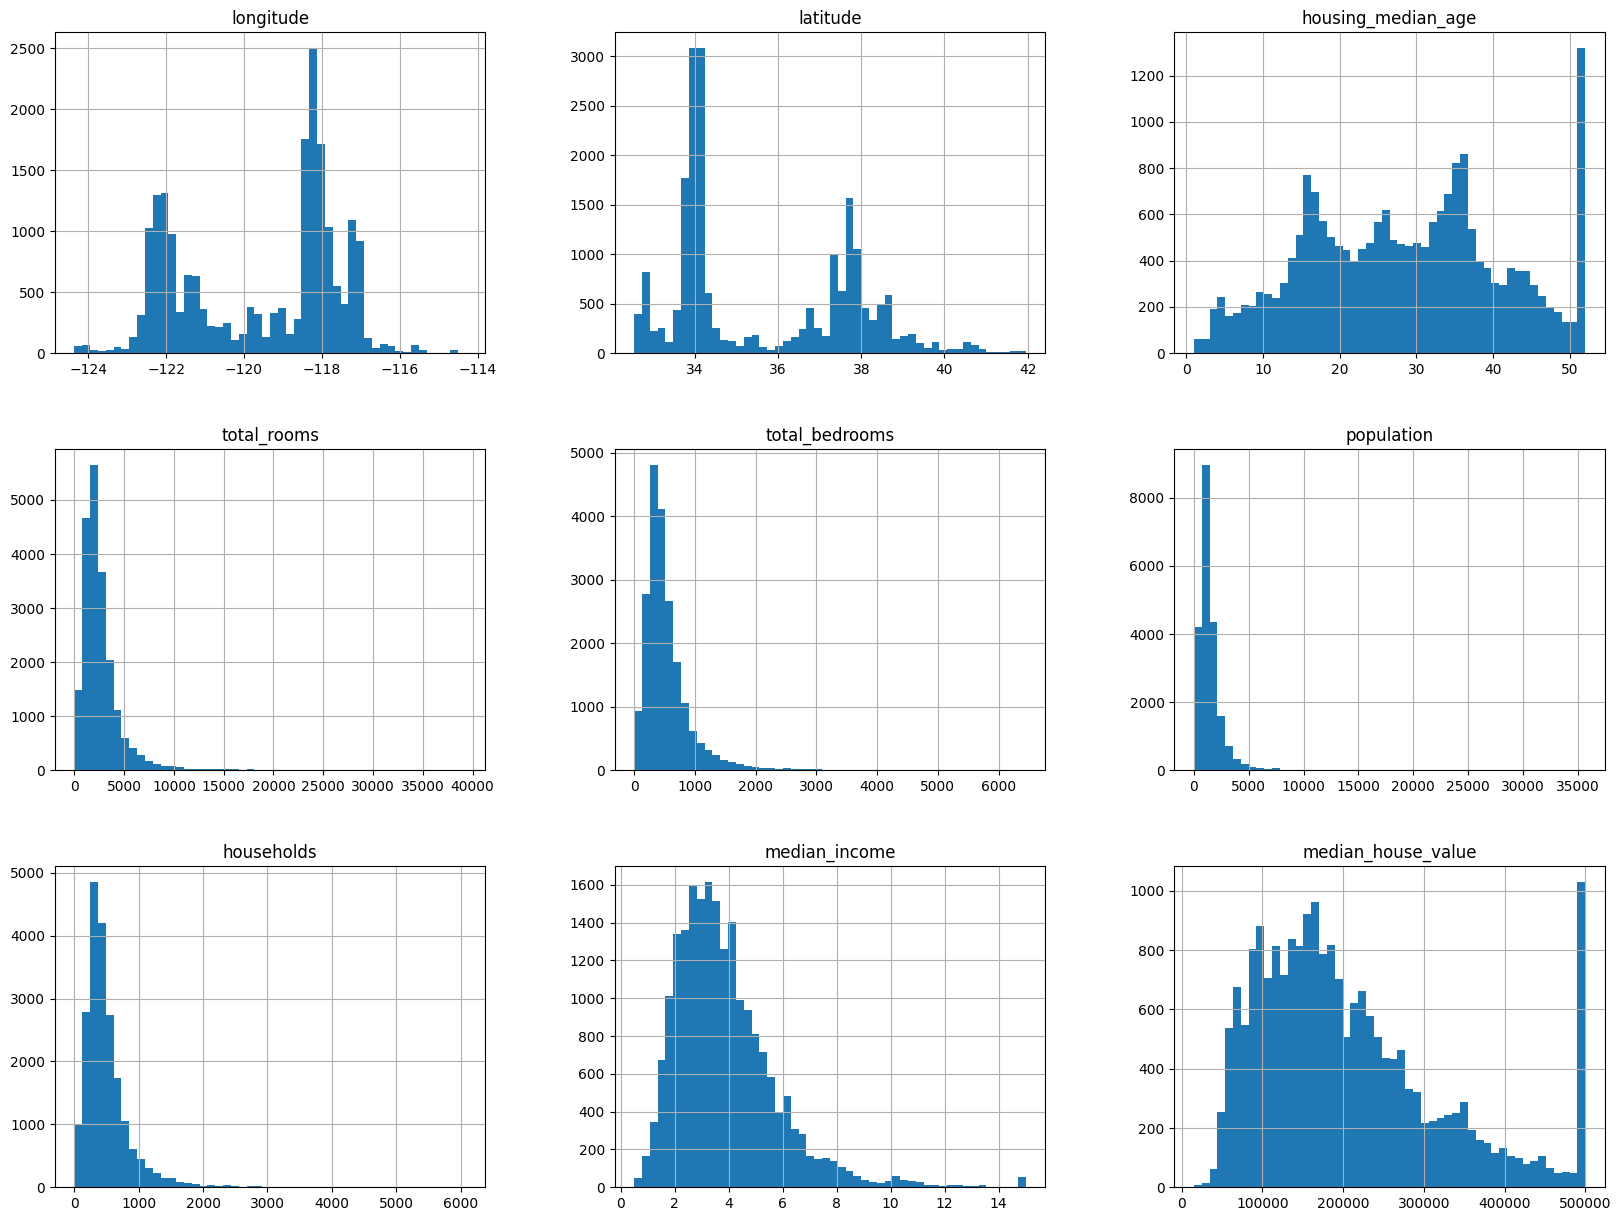

In [66]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15)) # bins change how big/small the x axis increments are (more bins = finer data plotted )
plt.show()

# Test Set
- sklearn's train_test_split method:
  - The code:

```
      from skelarn.model_selection import train_test_split
      train_set, test_set = train_test_split(housing, test_size = 0.2, random_state = 42)
```


- stratified shuffle split
  - The code:


```
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state = 42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
  strat_train_set_n = housing.iloc[train_index]
  strat_test_set_n = housing.iloc[test_index]
  strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0]
```
10 different stratified splits of the same dataset are generated and then the first one is chosen


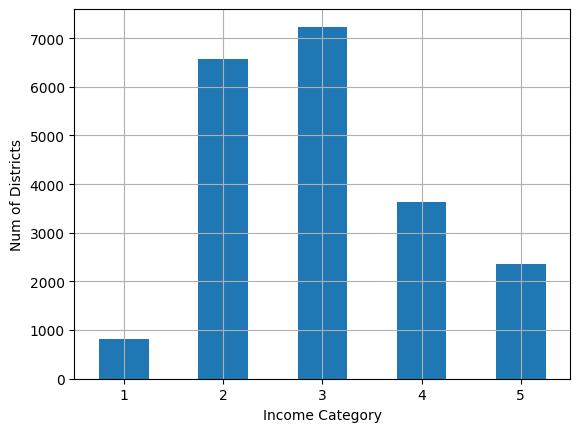

In [67]:
# creating the income category for the stratified shuffle split

import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins = [0,1.5,3.0,4.5,6.0,np.inf],
                               labels = [1,2,3,4,5])


housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid = True) #visualisation of the income category
plt.xlabel("Income Category")
plt.ylabel("Num of Districts")
plt.show()

In [68]:
#the stratified split

from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state = 42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
  strat_train_set_n = housing.iloc[train_index]
  strat_test_set_n = housing.iloc[test_index]
  strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0]

In [69]:
(strat_train_set["income_cat"].value_counts() /len(strat_train_set)).sort_index()

,count
income_cat,
1,0.039789
2,0.318859
3,0.350594
4,0.176296
5,0.114462


In [70]:
(strat_test_set["income_cat"].value_counts() /len(strat_test_set)).sort_index()

,count
income_cat,
1,0.039971
2,0.318798
3,0.350533
4,0.176357
5,0.114341


Both train and test have very similar proportions. The spit based on the income categories was a success.
The income category feature can now be deleted (if not needed)

In [71]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis = 1, inplace = True)

/tmp/ipykernel_14423/2104711148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis = 1, inplace = True)
/tmp/ipykernel_14423/2104711148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis = 1, inplace = True)


In [72]:
#double checking
print("Strat Train Cols: ", strat_train_set.columns)
print("Strat Test Cols: ", strat_test_set.columns)

Strat Train Cols:  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
Strat Test Cols:  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


# Exploring and Visualising the Data (for Insights)

In [73]:
housing = strat_train_set.copy()

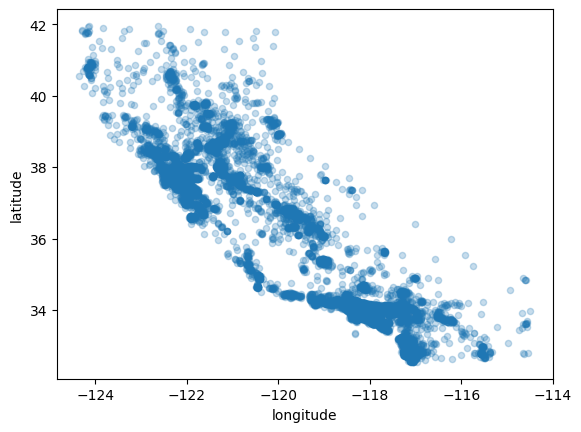

In [74]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", alpha = 0.25) # alpha controls how transparent the datapoints are -> 1.0 = opaque, 0.0 = transparent
plt.show()

#high density areas are much more visible

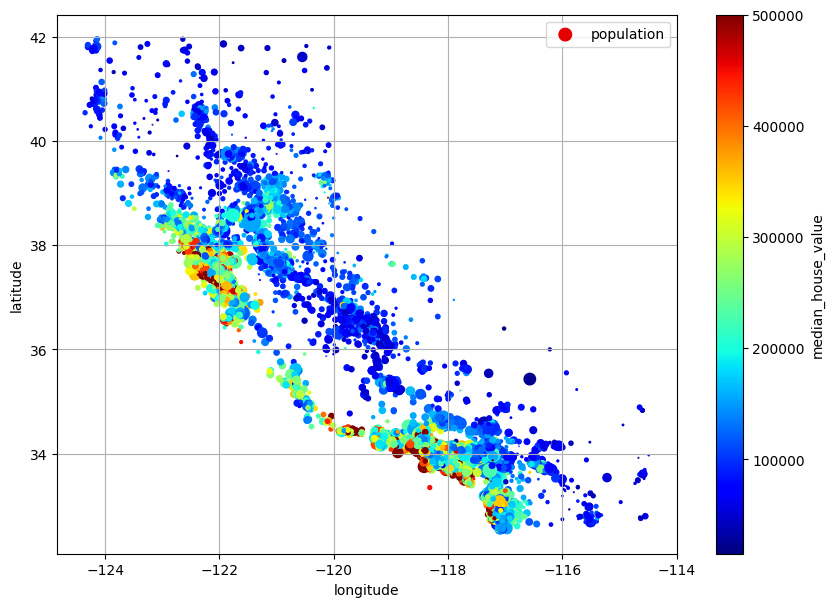

In [75]:
# longitude, latitude and median house value on one plot

housing.plot(kind = "scatter",
             x = "longitude",
             y= "latitude",
             grid  = True,
             s = housing["population"]/100,
             label = "population",
             c = "median_house_value",
             cmap = "jet",
             colorbar = True,
             legend = True,
             figsize = (10,7),
             sharex = False) #sharex = ensures that all subplots display the same x-axis limits, ticks and scale




plt.show()

**Correlations**

In [76]:
corr_matrix = housing.corr(numeric_only = True, method="pearson")

corr_matrix["median_house_value"].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


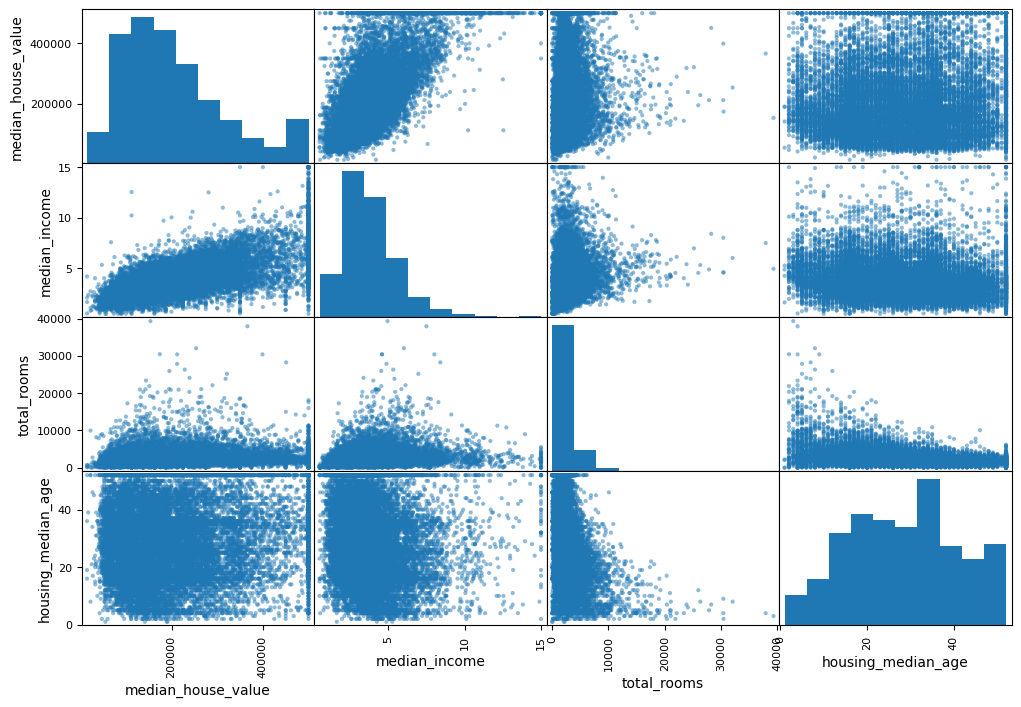

In [77]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]


scatter_matrix(housing[attributes], figsize = (12,8))
plt.show()

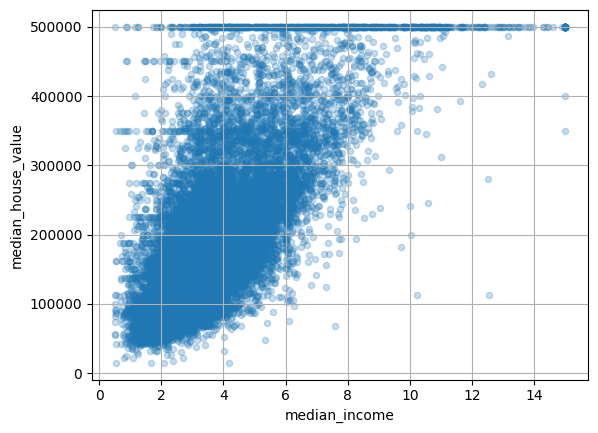

In [78]:
housing.plot(x = "median_income", y = "median_house_value", kind = "scatter", grid = True, alpha = 0.25)
plt.show()

# Combining Attributes (Feature Engineering)

In [79]:
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]


In [80]:
corr_matrix = housing.corr(numeric_only = True, method="pearson")

corr_matrix["median_house_value"].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


In [81]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
 10  rooms_per_house     16512 non-null  float64
 11  bedrooms_ratio      16344 non-null  float64
 12  people_per_house    16512 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.8+ MB


# Preparing the Data for Machine Learning

In [82]:
housing_labels = housing["median_house_value"].copy()

housing = housing.drop("median_house_value", axis = 1) #.drop() also creates a copy of the dataset and doesnt affect "strat_train_set", axis = 1 is columns


In [83]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
 9   rooms_per_house     16512 non-null  float64
 10  bedrooms_ratio      16344 non-null  float64
 11  people_per_house    16512 non-null  float64
dtypes: float64(11), object(1)
memory usage: 1.6+ MB


**Data Cleaning**

In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = "median")

housing_num = housing.select_dtypes(include = [np.number])

imputer.fit(housing_num)

X = imputer.transform(housing_num) # output of this = NumPy array. X has no column names nor index


In [85]:
housing_transformed = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index) #wrap X in a DataFrame and recover the column names and index from housing_num

**Text and Categorical Attributes**

In [86]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [87]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
housing_cat_hot = cat_encoder.fit_transform(housing_cat)

housing_cat_hot_transformed = pd.DataFrame(
    housing_cat_hot,
    columns=cat_encoder.get_feature_names_out(["ocean_proximity"]),
    index=housing_cat.index
)

housing_cat_hot_transformed.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0


**Feature Scaling and Transformation**

In [88]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler(feature_range = (-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num_std_scaled = StandardScaler().fit_transform(housing_num)

In [89]:
from sklearn.metrics.pairwise import rbf_kernel

age_similar_to_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma = 0.1)


**Transformation Pipeline**

In [90]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])



In [91]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [92]:
df_housing_num_prepared.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_house,bedrooms_ratio,people_per_house
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.866027,2.153743,-0.330204
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,0.024550,-0.569651,-0.253616
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,-0.041193,-0.215784,-0.051041
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,-0.034858,-0.154314,-0.141475
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,-0.666554,1.132023,-0.306148


In [93]:
num_pipeline.steps

[('imputer', SimpleImputer(strategy='median')),
 ('std_scaler', StandardScaler())]

In [94]:
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

In [95]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [96]:
housing_prepared = preprocessing.fit_transform(housing)

In [97]:
housing_prepared_df = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)

In [98]:
housing_prepared_df.head(2)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-1__rooms_per_house,pipeline-1__bedrooms_ratio,pipeline-1__people_per_house,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.866027,2.153743,-0.330204,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,0.024550,-0.569651,-0.253616,1.0,0.0,0.0,0.0,0.0


In [99]:
preprocessing.get_feature_names_out()

array(['pipeline-1__longitude', 'pipeline-1__latitude',
       'pipeline-1__housing_median_age', 'pipeline-1__total_rooms',
       'pipeline-1__total_bedrooms', 'pipeline-1__population',
       'pipeline-1__households', 'pipeline-1__median_income',
       'pipeline-1__rooms_per_house', 'pipeline-1__bedrooms_ratio',
       'pipeline-1__people_per_house',
       'pipeline-2__ocean_proximity_<1H OCEAN',
       'pipeline-2__ocean_proximity_INLAND',
       'pipeline-2__ocean_proximity_ISLAND',
       'pipeline-2__ocean_proximity_NEAR BAY',
       'pipeline-2__ocean_proximity_NEAR OCEAN'], dtype=object)

In [100]:
housing_prepared = housing_prepared_df.copy()

In [101]:
housing_prepared.shape

(16512, 16)

In [102]:
from sklearn.compose import make_column_selector, make_column_transformer,ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]







def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age


housing_prepared_geron = preprocessing.fit_transform(housing)
housing_prepared_df_geron = pd.DataFrame(
    housing_prepared_geron,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)


In [103]:
housing_prepared_df_geron.head(2) # this df contains the bedroom ratios, plus the similarity clusters geron made

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age,remainder__rooms_per_house,remainder__bedrooms_ratio,remainder__people_per_house
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,8.708837e-08,9.712456e-01,...,5.740031e-01,0.0,0.0,0.0,1.0,0.0,1.861119,-0.866027,2.153743,-0.330204
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,1.181328e-01,9.738096e-14,...,2.275194e-10,1.0,0.0,0.0,0.0,0.0,0.907630,0.024550,-0.569651,-0.253616


In [104]:
housing_prepared_df_geron.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bedrooms__ratio                  16512 non-null  float64
 1   rooms_per_house__ratio           16512 non-null  float64
 2   people_per_house__ratio          16512 non-null  float64
 3   log__total_bedrooms              16512 non-null  float64
 4   log__total_rooms                 16512 non-null  float64
 5   log__population                  16512 non-null  float64
 6   log__households                  16512 non-null  float64
 7   log__median_income               16512 non-null  float64
 8   geo__Cluster 0 similarity        16512 non-null  float64
 9   geo__Cluster 1 similarity        16512 non-null  float64
 10  geo__Cluster 2 similarity        16512 non-null  float64
 11  geo__Cluster 3 similarity        16512 non-null  float64
 12  geo__Cluster 4 simi

In [105]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__rooms_per_house',
       'remainder__bedrooms_ratio', 'remainder__people_per_house'],
      dtype=object)

**Selecting and Training a Model**

In [106]:
housing_prepared_geron = housing_prepared_df_geron.copy()

In [107]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared_geron, housing_labels)

LinearRegression()

In [108]:
housing_lin_reg_predictions = lin_reg.predict(housing_prepared_geron)
housing_lin_reg_predictions[:5].round(3)


array([252709.536, 372010.926, 123842.626,  95025.233, 323582.226])

In [109]:
housing_labels[:5]# first one is meant to be off by 200k, the values match the book/geron

,median_house_value
13096,458300.0
14973,483800.0
3785,101700.0
14689,96100.0
20507,361800.0


In [110]:
from sklearn.metrics import root_mean_squared_error

lin_mse = root_mean_squared_error(housing_labels, housing_lin_reg_predictions)
lin_mse #An error of $67,746 => this is model underfitting the data, features didnt provide enough information to make good predictions or model isnt strong enough
# ways to fix it is to select a stronger model, use better features, reduce constraints on the model

67746.47899308811

In [111]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared_geron, housing_labels)

DecisionTreeRegressor(random_state=42)

In [112]:
housing_tree_reg_predictions = tree_reg.predict(housing_prepared_geron)
housing_tree_reg_predictions[:5].round(3)

array([458300., 483800., 101700.,  96100., 361800.])

In [113]:
tree_rmse = root_mean_squared_error(housing_labels, housing_tree_reg_predictions)
tree_rmse

# a training error of 0 (or very low means) that there is overfitting whi

0.0

**Evaluation Using Cross Validation**

In [114]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing_prepared_geron, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(tree_rmses).describe()

# mean error is about 66,000, this is the validation error of decision tree

,0
count,10.000000
mean,66523.637379
std,2087.015919
min,63992.311427
25%,64645.412243
50%,66218.101791
75%,68515.970106
max,69519.461629


In [115]:
# error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, housing_prepared_geron, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()
# mean error is about 69,000

,0
count,10.000000
mean,68798.419155
std,3179.487477
min,64416.788307
25%,67735.442390
50%,68454.400893
75%,68884.607056
max,76996.000501


In [116]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)

forest_reg.fit(housing_prepared_geron, housing_labels)

RandomForestRegressor(random_state=42)

In [117]:
forest_rmses = - cross_val_score(forest_reg,housing_prepared_geron,housing_labels, scoring="neg_root_mean_squared_error", cv=10)

# took about 10-15 mins to run

In [118]:
pd.Series(forest_rmses).describe()

# better mean error, around 47k, 20k better than linear regression and decision trees

,0
count,10.000000
mean,47045.690619
std,974.431964
min,45932.439415
25%,46330.826144
50%,47042.511088
75%,47370.295298
max,49277.558152


Before working on hyperparamter tuning, shortlist 3-5 different promising models (e.g. SVM with different kernels, neural networks etc)

**Fine Tuning the model**

In [119]:
### GRID SEARCH

from sklearn.model_selection import GridSearchCV
full_pipeline = Pipeline([
    ("random_forest", RandomForestRegressor(random_state=42)),
])

param_grid = [
    {
        "random_forest__n_estimators": [3, 10, 30],
        "random_forest__max_features": [4, 6, 8],
    },
    {
        "random_forest__n_estimators": [30, 50, 100],
        "random_forest__max_features": [6, 8, 10],
    },
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing_prepared_geron, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'random_forest__max_features': [4, 6, 8],
                          'random_forest__n_estimators': [3, 10, 30]},
                         {'random_forest__max_features': [6, 8, 10],
                          'random_forest__n_estimators': [30, 50, 100]}],
             scoring='neg_root_mean_squared_error')

In [120]:
grid_search.best_params_

{'random_forest__max_features': 6, 'random_forest__n_estimators': 100}

In [123]:
### RANDOMISED SEARCH

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'random_forest__n_estimators': randint(low=3, high=100),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing_prepared_geron, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78358388a6c0>,
                                        'random_forest__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7835838892b0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [124]:
rnd_search.best_params_

{'random_forest__max_features': 3, 'random_forest__n_estimators': 90}

**Analysing the Best Models + Their Errors**

In [125]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.16, 0.04, 0.04, 0.04,
       0.03, 0.05, 0.05, 0.04, 0.03, 0.03, 0.04, 0.01, 0.09, 0.  , 0.  ,
       0.01, 0.02, 0.04, 0.05, 0.04])

In [129]:
sorted_feature_importances = sorted(
    zip(feature_importances, housing_prepared_geron.columns),
    reverse=True
)

sorted_feature_importances

[(np.float64(0.16191199077962465), 'log__median_income'),
 (np.float64(0.08520983269746714), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.05505964364728268), 'bedrooms__ratio'),
 (np.float64(0.05062087491791101), 'remainder__bedrooms_ratio'),
 (np.float64(0.049898041116279095), 'geo__Cluster 4 similarity'),
 (np.float64(0.04706323416105214), 'rooms_per_house__ratio'),
 (np.float64(0.046489250149665984), 'people_per_house__ratio'),
 (np.float64(0.04503251620242617), 'geo__Cluster 5 similarity'),
 (np.float64(0.044741512796804064), 'geo__Cluster 9 similarity'),
 (np.float64(0.04430321339592272), 'remainder__people_per_house'),
 (np.float64(0.0408934261971833), 'geo__Cluster 2 similarity'),
 (np.float64(0.03992342233277938), 'remainder__rooms_per_house'),
 (np.float64(0.038530610827422894), 'geo__Cluster 1 similarity'),
 (np.float64(0.037940646837107884), 'geo__Cluster 6 similarity'),
 (np.float64(0.03525807489794523), 'geo__Cluster 0 similarity'),
 (np.float64(0.032913830105375665), 'g

**Evaluating on the Test Set**

In [132]:
from sklearn.metrics import root_mean_squared_error
import pandas as pd

# 1. Split test set into features and labels
X_test = strat_test_set.drop("median_house_value", axis=1).copy()
y_test = strat_test_set["median_house_value"].copy()

# 2. Add the same manually engineered columns that existed during training
X_test["rooms_per_house"] = X_test["total_rooms"] / X_test["households"]
X_test["bedrooms_ratio"] = X_test["total_bedrooms"] / X_test["total_rooms"]
X_test["people_per_house"] = X_test["population"] / X_test["households"]

# 3. Apply the already-fitted preprocessing object
X_test_prepared = preprocessing.transform(X_test)

# 4. Optional but recommended: convert back to DataFrame with same columns as training data
X_test_prepared = pd.DataFrame(
    X_test_prepared,
    columns=housing_prepared_geron.columns,
    index=X_test.index
)

# 5. Predict using your final random forest pipeline
final_predictions = final_model.predict(X_test_prepared)

# 6. Evaluate
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

44558.68010851345


In [133]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval


In [134]:
rmse_lower, rmse_upper

(np.float64(42607.20006091921), np.float64(46735.6109469524))

 # Notes/Ideas whilst Learning:

**Ideas**
- "Many Histograms are skewed right: they extend much futher to right of the median than to the left"
    - To confirm, plot the mean, median, mode (before transforming) then after transformation to check if the data is still skewed

- Whats the difference betweeen the different correleation coefficients (Pearson, Spearman, Kendall)


```
corr_matrix = housing.corr(numeric_only = True, method="pearson")
```
- Evaluate the effects of KNNImputer and Iterative Imputer against SimpleImputer

- Build a custom transformer that can take the input data that is not gaussian, run multiple transofrmations on it e.g. squared, sqrt, log, exponential etc and the for each one measure its skewness, normality, mean etc to see which one returned a transformation that is closest to a gaussian distribution.

- A potential custom transformer for peak-detection:
  1. Build histogram counts
  2. Find local maximum bins
  3. Compute peak strength
  4. Keep bins above a threshold
  5. Use those bin centres as RBF centres
    - Code Logic - Calculate how much bin i is above each neighbour:

```
for each bin i from 1 to len(counts)-2:

    left_diff = counts[i] - counts[i-1]
    right_diff = counts[i] - counts[i+1]

    if left_diff > 0 and right_diff > 0:
        this is a peak candidate

        peak_strength = min(left_diff, right_diff)

        if peak_strength is large enough:
            keep it as a meaningful peak

```
    - Then plot bin index vs peak strength -> visual confirmation of which bins are strongest. (Can also use scipy.signal.find_peaks (where I can filter peaks by height, prominence, widht, distance between peaks) or KDE


**Notes**
- Test Set Splits
    - sklearn's train_test_split method:
      - random sampling method - can introduce a significant sampling bias if the data set is small enough. The train-test split should be representitive of the data in the whole dataset. For example, US pop. is 51.1% female and 48.9% male. If a company calls 1000 people for answers to a questionnaire, this ratio should be maintained i.e. 511 females, 489 males. - This is Stratified sampling, it prevents bias results that can occur through purely random sampling

    - stratified shuffle split:
      - The stratified shuffle split, ensure the train-test sets are representive of the various categories in the dataset. By adding in `housing["income_cat"]` the splits will be representive of the various categories in the dataset

- Cleaning the Data
  - Most ML algos cannot work with missing features. There are 3 options to fix the missing features issue


1.   Removing the districts (i.e. rows with missing data)
2.   Remove the whole feature/coloumn/ attribute
3.   Imputation (mean, median, zero, etc)


      ```
      Option 1 -

      housing.dropna(subset = ["total_bedrooms"], inplace = True)
      ```

      ```
      Option 2 -
      housing.drop("total_bedrooms", axis = 1)
      ```


      ```
      Option 3 -
      median = housing["total_bedrooms"].median()
      housing["total_bedrooms"].fillna(median, inplace = True)
      ```

  Option 3 can be done using Scikit-Learns SimpleImputer class as well. Option 3 is only for numerical attributes therefore need to create a copy of the data with numerical attributes only. In this case, only the "total_bedrooms" column had missing data but applying the imputer to all of the data is safer incase future data has missing values somewhere else.


```
# Num only data

housing_num = housing.select_dtypes(inlcude = [np.number])

# Simple Imputer instance

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

#Fitting the imputer instance

imputer.fit(housing_num)


```
  The imputer stores the computed median of each attribute in the statistics_ instance.
```
imputer.statistics_
```
  The output is like this: array([-118.51, 34.26, 29. ,2125 .....])
```
housing_num.median().values
```
  Which matches the output of the median values of housing_num.
  The output is like this: array([-118.51, 34.26, 29. ,2125 .....])


  The imputer can then be used to transfor the training set by replacing the missing values with the learned medians. Still applies to num features only (if imputer is a numerical one)

  X = imputer.transform(housing_num)

```
  X = imputer.transform(housing_num)
```
  Missing values can be replaced by the mean or most frequent values.
  strategy = "mean" or strategy = "most_frequent". Can also do constant value as well strategy = "constant", or fill_value = ...
  constant and fill_value are suitable for non-numerical data


  KNNImputer and IterativeImputer are more powerful imputers in the sklearn.impute package:
  - KNNImputer = replaces each missing value with the mean of the k-nearest neighbours' values for that feature. The distance is based on all available features.

  - IterativeImputer = trains a regression model per feature to predict the missing values based on all other available features. It then trains the model again on the updated data. This is repeated several times, and the models and replacement values are improved at each iteration.

  #Encoding Categorical Data

  - OrdinalEncoder vs OneHotEncoder:
      - OrdinalEncoder:
        - Ordinal Encoder will lable stuff as 1,2,3,4 etc. This can be an issue if the data thats being encoded has no actual relation to numbers. ML algos will assume that the value assigned to 1 and the value assigned to 2 are close to each other due to the numbers and that 1 is far from 4 even though thats not the case. The values that are closer to together e.g. 1 and 2 may be seen as more similar compared to values further apart e.g. 1 and 4. This is fine in some cases, e.g. "good", "bad and "worse". "good" is equally close to "bad" as "bad" is to "worse".
      - OneHotEncoder:
        - OneHotEncoder will lable stuff as 1s and 0s. For example if a feature column has categorical options of "inland", "near bay", and "near ocean" then OneHotEncoder returns a matrix of 3 seperate features ( "inland", "near bay", and "near ocean") each feature will have rows of 1s and 0s based on if that rows was positive for the feature column having that feature. For example, if the feature column in one row had "inland" in one row, OneHotEncoding will be 3 columns of [1,0,0] with the columns being "inland", "near bay", and "near ocean" respectively. This can be an issue because when a categorical column has hundreds or thousands of categories then OneHotEncoding can return a massive matrix.



  # Feature Scaling and Transformation
  Most ML algos will not do well with data that has different scales. For example the housing dataset has median income ranging from 0 to 15, and total number of rooms ranging from 6 to 39320. ML algos will be biased towards  the larger range.
  - Standardisation and Min-Max scaling are two methods of getting the attributes to the same scale.
    - Min-max Scaling aka normalisation is the simplest. Values are shifted and rescaled so that they end up between 0 and 1.
      - subtract the minimum value and then divide by (max-min)
      - Scikit-Learn has a transformer for this: MinMaxScaler which has a hyperparameter called feature_range allowing the range to be adjusted e.g. 0 to 1 or -1 to 1 (better for neural nets).


  ```
  from sklearn.preprocessing import MinMaxScaler
  min_max_scaler = MinMaxScaler(feature_range = (-1,1))
  housing_min_max_scaled = min_max_scaler.fit_transform(housing_num)
  ```
    - Standardisation:
      - First subtracts the mean value therefore standardised values have a zero mean.
      - Then divide the result by standard deviation therefore standardised values have an std of 1.
      - Standardisation is much less effected by outliers and does not restrict the values to a specific range.
      - Scikit-learn has a transformer for this:


```
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)
```




  Notes:

   - Ensure that scalers are fitted to training data only. Never use fit() and fit_transform() for anything other than the training set. Once the scaler has been trained on the training set, transform() can be used on any other set i.e. validation, test and even new data. Set the *clip* hyperparameter to True so that if new data is outside the range of the training data it can be scaled according to the training data.
   - When a feature's distribution is heavy tailed i.e. values from the mean are not exponentially rare, both min-max and std scaling will squash the values down to a small range. Not good. Therefore before scaling, transform the data and get the distribution to be as symmetrical i.e. Gaussian.
   - For positive features, replace the feature with its square root, or raise it to a power between 0 and 1. Or try replacing it with the logarithim of the feature if the tail is long and heavy.
   - Bucketizing is another appraoch i.e. chop the feature into roughly equal sized buckets and replace the feature value with the index of the bucket it belongs to. ( similar to the stratified sampling example with the income_cat feature). Bucketizing (with equal sized buckets) results in an approximately a uniform distribution therefore further scaling is not required.

   - With multimodal (two or more peaks) distribution e.g. housing_median_age, bucketising is also useful. But treat the bucketIDs as categories (therefore encode them) This is to allow a regression model to learn different rules/patterns for different ranges of this feature value. Given that OneHotEncoding can result in multiple "featurs" avoid having to many buckets.
   - Another approach to multimodal distributions is to add a feature of the main modes, representing the similarity between features. For example, housing_median_age. The housing distribution has a special value around 35yrs i.e. 35yrs is a peak in the distribution of the median age. Then instead of giving the model the raw age value a new feature can be created that measures: "how similar is this house's age to 35". The method is to use a radial basis function (RBF):
    - exp(-gamma(x-35)**2)
    
    x = house's median age,
    
    35 = special refrence, aka the mode or another fixed point.
    
    gamma = controls how quickly similarity falls as you move away from 35 (controls the width of the similarity bump, small gamma = ages near 35 and somewhat far away still count as similar, large gamma, ages close to 35 count as similar.

    exp = its an exponential function.
  
  Can use sklearn's rbf_kernel() function to create a new gaussian rbf feature


```
  from sklearn.metrics.pairwise import rbf_kernel
  age_similar_to_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma = 0.1)

```
  - An RBF features says how close is this house to an important age group

  - This can also be repeated for multiple modes e.g. 50, 60 75 etc therefore multiple new features can be created such as: age_similar_to_50,age_similar_to_60,age_similar_to_75.

  To know when to do this and for what peaks:
  
    1. Plot the feature distribution.
    2. Identify clear peaks or suspicious regions.
    3. Add RBF features around those values.
    4. Test whether validation performance improves.
    5. Keep the features only if they help.

  Definitions of a peak:
  - Local maximum - use the gradients to work out the peak. Only keep the peak if the difference between before peak and peak and difference between peak and after peak are both high. (this is the exact method, but with real world data approximations may need to be used)
  - Use the 5% rule - Only keep a peak of the region around the peak contains atleast 5% of the total dataset.
    - Region around the peak:
        1. Find a peak bin.
        2. Look left and right around that peak until the histogram dips.
        3. Count how many data points are inside that whole peak region.
        4. If that count is at least 5% of the data, keep the peak.

  Regarding transformations of features, sometimes a target feature may need to be transformed as well. i.e. if the target distribution has a heavy tail, then the target could be replaced by its logarithim. In this case the ML model will predict the log of the target i.e. log of the median house value. Therefore will need to work out the exponential of the prediction to get the actual value.

  Most Scikit-learns transformers have an inverse_transform() method that computes the inverse of their transformations.



```
# Example code - not actually used

from sklearn.linear_model import Linear Regression

target_scalar = StandardScaler()
scaled_lables = target_scaler.fit_transform(housing_lables.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_lables)

some_new_data = housing[["median_income]].iloc[:5] # example new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)


In this example, the lables are converted from a Pandas Series to a DataFrame because the StandardScaler needs 2D inputs.
```


## Custom Transformers

Reqiured for custom transformations e.g. transformations, cleanup operations, combining specific attributes etc.

If a transformation doesnt require any training then a function that takes NumPy arrays as inputs and outputs the transformed array. E.g. transforming a feature with a heavy tail distributions by replacing them with their logarithims (for this the feature has to be positive and right-tailed)



```
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func = np.exp)
log_population = log_transformer(housing[["population"]]

# inverse_func argument = optional, useful if the transfomer is going to be used in a TransformedTargetRegressor
```
Note - Theres no inverse funciton for the rbf kernel, since there are always 2 values at a given distance from a fixed point. If 2 features are passed to the rbf kernel as an array it will compute the 2D (Eucledian) distance between the two to measure similarity. e.g. geographic similarity: how similar is each district to San Francisco

```
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, kw_args = dict(Y = [sf_coords], gamma = 0.1))

sf_similar = sf_transformer.transform(housing[["latitude", "longitude"]])
```
Function transformers are very good for transforming but cannot do any training. For that, need BaseEstimator and TransformerMixin. The example below recreates StandardScalar from before:

```
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted


class StandardScalerClone(BaseEstimator, TransformerMixin):

  def __init__(self, with_mean = True) # cant use *args or **kwargs
    self.with_mean= with_mean

  def fit(self, X, y = None): # y is needed even though its not used
    X = check_array(X) #checks if X is an array with finite float values
    self.mean_ = X.mean(axis = 0)
    self.scale = X.std(axis = 0)
    self.n_features_in_ = X.shape[1] #every estimator stores this in fit
    return self # always need to return self

  def transform(self, X):
    check_is_fitted(self)
    X = check_array(X)
    assert self.n_features_in_ == X.shape[1]
    if self.with_mean:
      X = X-self.mean_
    return X/self.scale_

# the validation packages contains several functions that are used to validate the inputs - Production code should always have them

# Scikit-Learn pipelines require the fit() method to have two inputs hence the X and y = None argument

# All scikit-learn estimators set n_features_in_ in the fit() method and they ensure that the data passed to transform() or predict() has the same number of features

# The fit() method must return self

```
  Custom Transformers often use other estimators in their implementation
  For example
```
from sklean.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
  def __init__(self, n_clusters, gamma, random_state = None):
    self.n_clusters = n_clusters
    self.gamma = gamma
    self.random_state = random_state

  def fit(self, X, y = None, sample_weight = None):
    self.kmeans = KMeans(self.n_clusters, random_state = self.random_state)
    self.kmeans_.fit(X, sample_weight = sample_weight)
    return self
  def transform(self, X):
    return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)

  def get_feature_names_out(self,names = None):
    return [f"Cluster {i} similarity for " for i in range(self.n_clusters) ]   

  cluster_simil = ClusterSimilarity(n_cluster = 10, gamma = 1.0, random_state = 42)
  similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]], sample_weight = housing_labels)


```

# Transformation Pipelines
There are many data transformation steps that need to happen in the right order. Scikit-Learn has a Pipeline class that helps wit sequences of transformations.

Example: Pipeline for numerical attributes, which imputes and then scales input features

```
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline(["impute", SimpleImputer(strategy="median")),
("standardise", StandardScaler()) )]
```
Rules of the Pipeline constructor:
- Takes a list of name/estimator pairs (this defines the steps and their order)
- Names can be anything but cannot have double underscores __
- The estimators must all be transformers i.e. they must have a fit_transform() method except for the last one which can be anything (transformer, predictor, or any other type of estimator)  

Making a pipeline(there are two ways - Pipeline and make_pipeline):

```
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])


housing_num_prepared = num_pipeline.fit_transform(housing_num)

# Code below turns it back into a df (from array)
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

num_pipeline.steps # will show the steps/information about the pipeline (on colab)



cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

# with make pipeline dont have to name the transformers

```




There are two ways to make the column transformation pipeline:
- ColumnTransformer:
  - This requires a list of the num attributes and a list of the categorical attributes
  - can use either pipeline (name the transformers) or make_pipeline (dont have to name transformers)

```
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]


preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

```

- Make_column Selector and Make column Transformer:
  - Dont have to manually write out the column names
  - Still requires defining the cat and num pipelines
```
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)
```

- Both use the fit_transform method

```
housing_prepared = preprocessing.fit_transform(housing)
```

by running the get feature names out method, it will output the all the features used in the transformer

```
preprocessing.get_feature_names_out()

```
## CHATGPT Q&A Notes: Why Géron Includes Preprocessing Inside the Pipeline

In the *Hands-On Machine Learning* workflow, Géron includes the preprocessing steps inside the `Pipeline` instead of preprocessing the data separately before training the model.

He does this because the pipeline keeps the **entire machine learning workflow together**:

```python
raw data → preprocessing → model training/prediction
```

Instead of doing:

```python
preprocess data first → train model separately
```

---

## 1. Your approach: preprocessing first, then training

Your workflow was roughly:

```python
housing_prepared = preprocessing.fit_transform(housing)

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
```

This means you manually transformed the raw housing data into a clean numerical dataset first. Then you trained the model on the already-prepared data.

This is not wrong. It works, and that is why your error metrics were similar to Géron’s.

### Pros of this approach

It is easier to understand when learning because each step is separate:

```text
Step 1: clean/transform the data
Step 2: train the model
Step 3: evaluate the model
```

It also lets you inspect the prepared dataset directly, which is useful when learning what each transformer is doing.

For example, you can look at:

```python
housing_prepared_df.head()
```

and understand the final features going into the model.

### Cons of this approach

The main issue is that it can create **data leakage** during cross-validation.

If you do this:

```python
housing_prepared = preprocessing.fit_transform(housing)
cross_val_score(model, housing_prepared, housing_labels)
```

then the preprocessing step has already seen the whole training dataset before cross-validation starts.

That means information from the validation folds may have influenced things like:

```python
SimpleImputer()
StandardScaler()
OneHotEncoder()
ClusterSimilarity()
```

This is not always a huge problem, but technically the validation fold is supposed to behave like unseen data. The model should not get any information from it during training or preprocessing.

Another drawback is that when you get new raw data later, you must remember to manually apply the same preprocessing before prediction:

```python
new_data_prepared = preprocessing.transform(new_data)
predictions = model.predict(new_data_prepared)
```

So the preprocessing and model are separated, which can become messy later.

---

## 2. Géron’s approach: preprocessing inside the pipeline

Géron does this:

```python
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
```

This means the pipeline takes raw data and handles the full process automatically:

```text
raw housing data
→ preprocessing
→ random forest model
→ prediction
```

So when fitting:

```python
full_pipeline.fit(housing, housing_labels)
```

the pipeline first preprocesses `housing`, then trains the random forest.

And when predicting:

```python
full_pipeline.predict(new_housing_data)
```

the pipeline automatically applies the same preprocessing before making predictions.

---

## 3. Why this matters for cross-validation

This is one of the most important reasons.

With Géron’s pipeline approach, cross-validation works properly.

For each fold, scikit-learn does something like this:

```text
Fold 1:
    fit preprocessing only on training fold
    transform training fold
    train model
    transform validation fold
    evaluate

Fold 2:
    fit preprocessing only on training fold
    transform training fold
    train model
    transform validation fold
    evaluate

Fold 3:
    same process again
```

This avoids leaking information from the validation fold into the preprocessing stage.

That gives a cleaner and more realistic estimate of model performance.

---

## 4. Why this matters for GridSearchCV

Géron is also tuning preprocessing parameters, not just model parameters.

For example:

```python
param_grid = [
    {
        "preprocessing__geo__n_clusters": [5, 8, 10],
        "random_forest__max_features": [4, 6, 8],
    }
]
```

This means GridSearchCV is testing combinations like:

```text
5 geo clusters + max_features = 4
5 geo clusters + max_features = 6
8 geo clusters + max_features = 4
8 geo clusters + max_features = 6
...
```

So the grid search is not only asking:

```text
What random forest settings are best?
```

It is asking:

```text
What full preprocessing + random forest combination is best?
```

This is more powerful because sometimes the best model depends on how the data was prepared.

For example, the best number of geographic clusters may affect how well the random forest performs.

---

## 5. Why your version still worked

Your version worked because you had already created a prepared dataset:

```python
housing_prepared_geron
```

So the model was still receiving good numerical features.

For example, the random forest still received:

```text
cleaned numerical features
encoded categorical features
engineered features
possibly scaled/transformed features
```

Therefore, it makes sense that your RMSE values were close to Géron’s.

The difference is not that your model was “wrong”; the difference is that Géron’s workflow is more robust and professional.

---

## 6. When your approach is okay

Your approach is okay when:

```text
You are learning
You want to inspect the transformed data manually
You are doing quick experiments
You are not tuning preprocessing parameters
You are not too worried about small leakage issues during early practice
```

For example:

```python
housing_prepared = preprocessing.fit_transform(housing)
forest_reg.fit(housing_prepared, housing_labels)
```

This is good for understanding the mechanics.

---

## 7. When Géron’s approach is better

Géron’s approach is better when:

```text
You are doing cross-validation
You are using GridSearchCV or RandomizedSearchCV
You want to tune preprocessing parameters
You want a clean final model
You want to avoid data leakage
You want the model to accept raw data directly
You want a deployment-ready workflow
```

This is the better professional workflow:

```python
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestRegressor())
])

full_pipeline.fit(housing, housing_labels)
```

Then later:

```python
full_pipeline.predict(new_raw_data)
```

No manual preprocessing step is needed.

---

## Main takeaway

Your workflow:

```text
Preprocess first → train model
```

Géron’s workflow:

```text
Raw data → preprocessing → model, all inside one pipeline
```

Your method is easier to understand at first and works for learning.

Géron’s method is better for proper machine learning because it:

```text
reduces data leakage
works cleanly with cross-validation
allows preprocessing hyperparameters to be tuned
keeps the workflow organised
makes future predictions easier
is closer to real-world deployment practice
```

So the best way to think about it is:

> Preprocessing separately is fine for learning and inspection.
> Putting preprocessing inside the pipeline is better for evaluation, tuning, and final modelling.





# Fine Tuning The Model
 - Two routes:
  - Grid Search and Randomised Search
    - Grid Search:
    Use Scikit-Learn's GridSearchCV class to search. Enter hyperparameters and it will use cross-validation to evaluate all possible combinations of the hyperparameter values.
    Example:

```
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

```
This method (with preprocessing involved as part of the hyperparameters) will search for the best preprocessing values as well. (The one in the code block doesnt have preprocessing)

With this example (preprocessing one) Scikit-Learn sees the "preprocessing__geo__n_clusters" it splits the string at the double underscores and then looks for the an estimator named "preprocessing" and finds the preprocessing ColumnTransformer. Then it looks for "geo" inside the Column Transfoer and finds the ClusterSimilarity transfer (used on latititude and longitude features).


Wrapping the preprocessing steps in a Scikit-Learn pipeline allows for tuning of the hyperparameter steps along with the model hyperparameterrs. E.g. increasing n_clusters may require increasing max_features as well

In this example code, there are 15 combinations of hyperparameter values. (dict 1 = 3x3 = 9, dict 2 = 2x3 = 6) and it will train the pipeline 3 times per combinates i.e. a total of 45 rounds of training. Then the best combination of parameters can be seen with:

```
grid_search.best_params_

```
and the best estimator can be accessed using:

```
grid_search.best_estimator_
```

The evaluation scores are also available to see with:

```
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head() #1st column is row ID

```

  - Randomized Search:
    Better option relative to GridSearchCV espescially when the hyperparameter search space is large. This class doesnt try all possible values. It evaluates a fixed number of combinations, selecting a random value for each hyperparameter at each iteration.
    Pros:
    - If some hyperparameters are continuous (or discrete with many possible value) and randomised search is ran for 1000 iterations then it wil explore 1000 different values for each of the hyperparameters whereas Grid seach explores the few values listed for each hyperparameter.
    - If a hyperparameter doesnt acctually make a difference (but thats not known at the moment). if it has 10 possible values, grid search will take 10 times longer but with randomised search it wont make a difference.
    - If there are 6 hyperparameters each with 10 possible values, then grid search means training the model 10^6 times. Whereas with Randomised search its for any number of iterations chosen.


  Each hyperparameter requires a list of possible values or a probabilty distribution
```
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

```

```
from sklearn.experimental import enable_halving_search_cv

from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.model_selection import HalvingGridSearchCV

```

The two above are hyperparameter search classes. Their goal is to use computational resources more effeciently by either training faster or explore a larger hyperparameter space.

In the first round, many hyperparameter combinations (aka candidates) are generaed using either the grid or random appraoch. These candidates are tehn used to train candidates that are evaluated with cross-validation. The training is carried out with limited resources i.e. small part of the training set - speeding up the first round of training.
Once the every candidate has been evaluated only the best ones go to the next round wher they are allowed more resources to compete. After multiple rounds the final candidates are evaluated with full resources.

To use those search classes the enabling halving search line needs to be imported - these are experimental hence require it.

Example of how its used:

```
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

halving_rnd_search = HalvingRandomSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42
)

```






**Bonus section: how to choose the sampling distribution for a hyperparameter**

* `scipy.stats.randint(a, b+1)`: for hyperparameters with _discrete_ values that range from a to b, and all values in that range seem equally likely.
* `scipy.stats.uniform(a, b)`: this is very similar, but for _continuous_ hyperparameters.
* `scipy.stats.geom(1 / scale)`: for discrete values, when you want to sample roughly in a given scale. E.g., with scale=1000 most samples will be in this ballpark, but ~10% of all samples will be <100 and ~10% will be >2300.
* `scipy.stats.expon(scale)`: this is the continuous equivalent of `geom`. Just set `scale` to the most likely value.
* `scipy.stats.loguniform(a, b)`: when you have almost no idea what the optimal hyperparameter value's scale is. If you set a=0.01 and b=100, then you're just as likely to sample a value between 0.01 and 0.1 as a value between 10 and 100.



# Analysing the Best Models and their errors

```
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

```

This gets the importance score for each of the attributes when making a prediction.

To get the scores next to their corresponding attributes:

```
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)


# requires preprocessing to be part of the pipeline. Since I didnt, I have to use a different method


sorted_feature_importances = sorted(
    zip(feature_importances, housing_prepared_geron.columns),
    reverse=True
)

sorted_feature_importances
```

The score give good information on what features are acctually good and what are not doing anything. For example, cat__ocean_proximity _island is not a good category for making accurate predictions. Whereas log median income achieved a high score demonstrating how good/important it was in achieving accurate predictions.

Note:
sklearn.feature_selection.SelectFromModel transformer can automatically drop the least useful features. When its fit, it trains a model, looks at its feature_importances attribute and selects the most useful feature. Then when transform() is called it drops the other features.

#Evaluating on the Test Set


My final RMSE was around 44,558, compared with Géron’s 41,424. The difference is likely because my RandomizedSearchCV only tuned the RandomForestRegressor hyperparameters, while Géron’s full pipeline also tuned preprocessing hyperparameters such as the number of geographic similarity clusters. Since location is highly predictive in the housing dataset, tuning the geo-clustering step can improve model performance.

My confidence interval for RMSE was approximately 42,607 to 46,735. Géron’s RMSE falls below this interval, suggesting his final model performed meaningfully better. However, my result is still in the same general range, and the difference is explainable by the fact that my preprocessing was performed separately and not included in the full hyperparameter search.


# Launching Model

```
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

# Example script to deploy the model

import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

```

# The "Correct Workflow" - ChatGPT
Asked CHATGPT to generate a workflow example that includes all the correct steps in the correct places, i.e. adding preprocessing to the pipeline so that it could be tuned, geo clustering etc.

# =============================================================================
# CORRECT END-TO-END WORKFLOW FOR THE CALIFORNIA HOUSING PROJECT
# =============================================================================
#
# Main lesson:
# The final model should include BOTH:
#   1. preprocessing
#   2. the machine learning model
#
# So the final workflow becomes:
#
#   raw data
#       ↓
#   preprocessing pipeline
#       ↓
#   random forest model
#       ↓
#   predictions
#
# This avoids the issue where the model expects preprocessed data but the test set
# is still raw. It also allows GridSearchCV / RandomizedSearchCV to tune both
# preprocessing hyperparameters and model hyperparameters.
#
# In your earlier workflow, you did:
#
#   housing_prepared = preprocessing.fit_transform(housing)
#   model.fit(housing_prepared, housing_labels)
#
# That works for learning, but at the test stage you then had to remember to
# manually transform X_test before prediction.
#
# In this corrected workflow, the final_model is a full Pipeline, so this works:
#
#   final_predictions = final_model.predict(X_test)
#
# because final_model automatically applies preprocessing internally.
# =============================================================================


# =============================================================================
# 1. IMPORTS
# =============================================================================

from pathlib import Path
import tarfile
import urllib.request

import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor


# =============================================================================
# 2. LOAD THE DATA
# =============================================================================
#
# Important:
# Use a fresh variable name like housing_full so you do not accidentally reuse
# a modified version of housing from earlier notebook cells.

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")

    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")

    return pd.read_csv(Path("datasets/housing/housing.csv"))


housing_full = load_housing_data()


# =============================================================================
# 3. CREATE THE STRATIFIED TRAIN/TEST SPLIT
# =============================================================================
#
# We create income_cat only for splitting.
# It should NOT be used as a normal model feature unless we intentionally want it.
#
# Why stratify?
# median_income is strongly related to median_house_value, so we want the train
# and test sets to have similar income distributions.

housing_full["income_cat"] = pd.cut(
    housing_full["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

strat_train_set, strat_test_set = train_test_split(
    housing_full,
    test_size=0.2,
    stratify=housing_full["income_cat"],
    random_state=42
)

# Drop income_cat from both sets after the split.
# We only needed it for stratified sampling.
strat_train_set = strat_train_set.drop("income_cat", axis=1)
strat_test_set = strat_test_set.drop("income_cat", axis=1)


# =============================================================================
# 4. SEPARATE FEATURES AND LABELS
# =============================================================================
#
# housing = raw training features
# housing_labels = target values
#
# Very important:
# Do NOT manually preprocess housing here.
# Do NOT manually add rooms_per_house, bedrooms_ratio, etc. here.
#
# Those engineered features will be created inside the preprocessing pipeline.

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()


# =============================================================================
# 5. CUSTOM TRANSFORMER: GEOGRAPHIC CLUSTER SIMILARITY
# =============================================================================
#
# This transformer:
#   1. takes latitude and longitude
#   2. uses KMeans to find geographic clusters
#   3. creates similarity features to those cluster centres using RBF similarity
#
# So instead of only giving the model raw latitude/longitude, we give it features
# like:
#   geo__Cluster 0 similarity
#   geo__Cluster 1 similarity
#   geo__Cluster 2 similarity
#   ...
#
# This helps the model learn location/neighbourhood effects.

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            n_init=10,
            random_state=self.random_state
        )
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(
            X,
            self.kmeans_.cluster_centers_,
            gamma=self.gamma
        )

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


# =============================================================================
# 6. RATIO FEATURE PIPELINES
# =============================================================================
#
# These create engineered ratio features inside the preprocessing pipeline.
#
# Examples:
#   total_bedrooms / total_rooms      -> bedrooms ratio
#   total_rooms / households          -> rooms per household
#   population / households           -> people per household
#
# This is better than manually adding columns to housing because:
#
#   1. The same transformations are automatically applied to train, validation,
#      test, and future data.
#
#   2. Cross-validation stays clean.
#
#   3. The final model can accept raw data directly.

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]


def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )


# =============================================================================
# 7. OTHER PREPROCESSING PIPELINES
# =============================================================================

# Log pipeline:
# Good for right-skewed positive features such as total_rooms, population, etc.
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

# Categorical pipeline:
# Handles missing categories and one-hot encodes ocean_proximity.
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

# Default numerical pipeline:
# Used for leftover numerical columns not explicitly handled above.
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Geographic similarity transformer:
cluster_simil = ClusterSimilarity(
    n_clusters=10,
    gamma=1.0,
    random_state=42
)


# =============================================================================
# 8. FULL PREPROCESSING PIPELINE
# =============================================================================
#
# This ColumnTransformer says:
#
#   - Create bedroom ratio from total_bedrooms and total_rooms
#   - Create rooms per household from total_rooms and households
#   - Create people per household from population and households
#   - Log-transform heavy-tailed numerical features
#   - Create geographic cluster similarity features from latitude/longitude
#   - One-hot encode categorical columns
#   - Apply default numerical preprocessing to remaining numerical columns
#
# The important detail:
# This preprocessing object expects RAW housing data.
# It creates the engineered features internally.

preprocessing = ColumnTransformer(
    transformers=[
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),

        ("log", log_pipeline, [
            "total_bedrooms",
            "total_rooms",
            "population",
            "households",
            "median_income"
        ]),

        ("geo", cluster_simil, ["latitude", "longitude"]),

        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline
)


# =============================================================================
# 9. FULL MODEL PIPELINE
# =============================================================================
#
# This is the key correction.
#
# The pipeline contains:
#
#   step 1: preprocessing
#   step 2: random forest
#
# So when we call:
#
#   full_pipeline.fit(housing, housing_labels)
#
# it automatically does:
#
#   preprocessing.fit_transform(housing)
#   random_forest.fit(housing_prepared, housing_labels)
#
# And when we call:
#
#   full_pipeline.predict(X_test)
#
# it automatically does:
#
#   preprocessing.transform(X_test)
#   random_forest.predict(X_test_prepared)

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])


# =============================================================================
# 10. RANDOMIZED SEARCH
# =============================================================================
#
# Here we tune both:
#
#   1. preprocessing hyperparameters
#   2. model hyperparameters
#
# This line:
#
#   "preprocessing__geo__n_clusters"
#
# means:
#
#   go into the full pipeline
#       -> find the "preprocessing" step
#       -> inside that, find the "geo" transformer
#       -> change its "n_clusters" hyperparameter
#
# This line:
#
#   "random_forest__max_features"
#
# means:
#
#   go into the full pipeline
#       -> find the "random_forest" step
#       -> change its "max_features" hyperparameter
#
# This is why including preprocessing inside the pipeline is powerful:
# the search can tune preprocessing choices and model choices together.

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=20),
}

rnd_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rnd_search.fit(housing, housing_labels)


# =============================================================================
# 11. VIEW BEST PARAMETERS AND CROSS-VALIDATION RESULTS
# =============================================================================

print("Best parameters:")
print(rnd_search.best_params_)

print("\nBest cross-validation RMSE:")
print(-rnd_search.best_score_)

# Optional: make the random search results easier to read.
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res = cv_res.sort_values(by="mean_test_score", ascending=False)

cv_results_table = cv_res[[
    "param_preprocessing__geo__n_clusters",
    "param_random_forest__max_features",
    "split0_test_score",
    "split1_test_score",
    "split2_test_score",
    "mean_test_score",
]].copy()

cv_results_table.columns = [
    "n_clusters",
    "max_features",
    "split0_rmse",
    "split1_rmse",
    "split2_rmse",
    "mean_test_rmse",
]

score_cols = ["split0_rmse", "split1_rmse", "split2_rmse", "mean_test_rmse"]
cv_results_table[score_cols] = -cv_results_table[score_cols].round().astype(np.int64)

print("\nTop random search results:")
display(cv_results_table.head())


# =============================================================================
# 12. ANALYSE FEATURE IMPORTANCES
# =============================================================================
#
# Because final_model is a full Pipeline, it contains:
#
#   final_model["preprocessing"]
#   final_model["random_forest"]
#
# The random forest gives us the importance values.
# The preprocessing step gives us the transformed feature names.
#
# Then we zip them together:
#
#   importance value -> transformed feature name
#
# Example:
#
#   0.18 -> log__median_income
#   0.07 -> cat__ocean_proximity_INLAND
#   0.05 -> geo__Cluster 12 similarity

final_model = rnd_search.best_estimator_

feature_importances = final_model["random_forest"].feature_importances_
feature_names = final_model["preprocessing"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

print("\nFeature importances:")
display(feature_importance_df)


# =============================================================================
# 13. FINAL TEST SET EVALUATION
# =============================================================================
#
# This is where your earlier workflow caused problems.
#
# Previously, your model only contained:
#
#   random_forest
#
# Therefore, you had to manually do:
#
#   X_test_prepared = preprocessing.transform(X_test)
#   final_predictions = final_model.predict(X_test_prepared)
#
# But now final_model contains:
#
#   preprocessing -> random_forest
#
# Therefore, this works directly:
#
#   final_predictions = final_model.predict(X_test)
#
# Do not call fit_transform on the test set.
# Do not manually add ratio columns to X_test.
# The pipeline handles all of that automatically.

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)

print("\nFinal test RMSE:")
print(final_rmse)


# =============================================================================
# 14. CONFIDENCE INTERVAL FOR THE TEST RMSE
# =============================================================================
#
# The final_rmse is one estimate of the model's generalisation error.
#
# The confidence interval gives a range that likely contains the true RMSE.
#
# Here we:
#
#   1. compute squared errors
#   2. create a confidence interval for the mean squared error
#   3. take the square root to convert it into RMSE units

confidence = 0.95

squared_errors = (final_predictions - y_test) ** 2

mse_confidence_interval = stats.t.interval(
    confidence=confidence,
    df=len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
)

rmse_confidence_interval = np.sqrt(mse_confidence_interval)

print("\n95% confidence interval for RMSE:")
print(rmse_confidence_interval)


# =============================================================================
# 15. FINAL SUMMARY NOTES
# =============================================================================
#
# Correct workflow summary:
#
#   1. Load raw data.
#   2. Create train/test split before doing serious preprocessing.
#   3. Separate training features and labels.
#   4. Build preprocessing steps inside a ColumnTransformer.
#   5. Put preprocessing and the model inside one Pipeline.
#   6. Use RandomizedSearchCV or GridSearchCV on the full Pipeline.
#   7. Fit the search object on raw training features, not preprocessed features.
#   8. Get the best full pipeline using rnd_search.best_estimator_.
#   9. Use final_model.predict(X_test) directly on raw test data.
#   10. Calculate final RMSE and confidence interval.
#
# Main lesson:
#
#   If preprocessing is outside the model pipeline:
#       - you must manually transform train, validation, test, and future data
#       - cross-validation can suffer from leakage if done carelessly
#       - hyperparameter search cannot tune preprocessing properly
#
#   If preprocessing is inside the model pipeline:
#       - train/test/future data are handled consistently
#       - cross-validation is cleaner
#       - GridSearchCV and RandomizedSearchCV can tune preprocessing and model
#         hyperparameters together
#       - the final model can accept raw input data directly
#
# This is the workflow to use for proper modelling.
# =============================================================================